In [223]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from helper_function import accuracy_fn, plot_decision_boundary

In [224]:
X, y = make_circles(n_samples = 1000, noise = 0.03, random_state = 42)

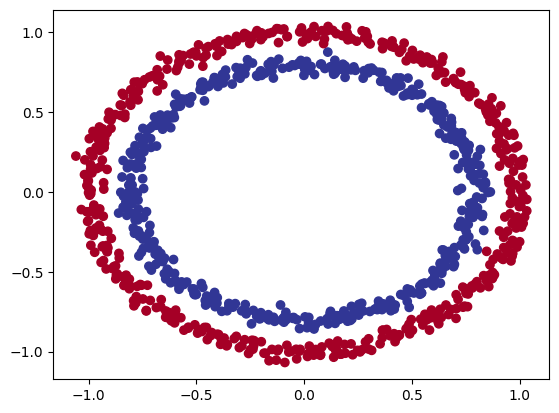

In [225]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [226]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)
X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [227]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)
X_train[:5]

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]])

In [228]:
len(X_train), len(X_test)

(800, 200)

In [229]:
y_train[:5]

tensor([1., 0., 0., 0., 1.])

In [230]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [231]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

In [232]:
model = CircleModel().to(device)
model

CircleModel(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [233]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

X_train[:5]

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]], device='mps:0')

In [234]:
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.1)

In [235]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [236]:
epochs = 100
total_epochs = []
losses = []
test_losses = []

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    train_accuracy = accuracy_fn(y_train, y_pred)

    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))
        test_accuracy = accuracy_fn(y_test, y_test_pred)

        test_loss = loss_fn(y_test_logits, y_test)
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)

    if epoch % (0.2 * epochs) == 0:
        print(f"Training Loss: {loss:.5f} | Testing Loss: {test_loss:.5f}")
        print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}")

Training Loss: 0.69295 | Testing Loss: 0.69394
Train Accuracy: 50.0 | Test Accuracy: 50.0
Training Loss: 0.20353 | Testing Loss: 0.19835
Train Accuracy: 99.375 | Test Accuracy: 97.5
Training Loss: 0.01162 | Testing Loss: 0.02676
Train Accuracy: 100.0 | Test Accuracy: 99.5
Training Loss: 0.00364 | Testing Loss: 0.01296
Train Accuracy: 100.0 | Test Accuracy: 99.5
Training Loss: 0.00222 | Testing Loss: 0.00857
Train Accuracy: 100.0 | Test Accuracy: 100.0


In [237]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

y_pred[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='mps:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='mps:0'))

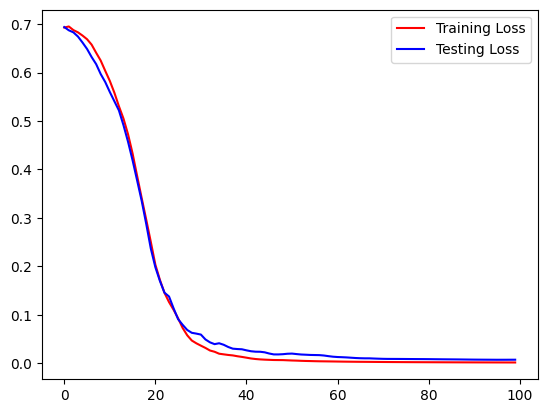

In [240]:
plt.plot(total_epochs, losses, label="Training Loss", c="red")
plt.plot(total_epochs, test_losses, label="Testing Loss", c="blue")
plt.legend()
plt.show()

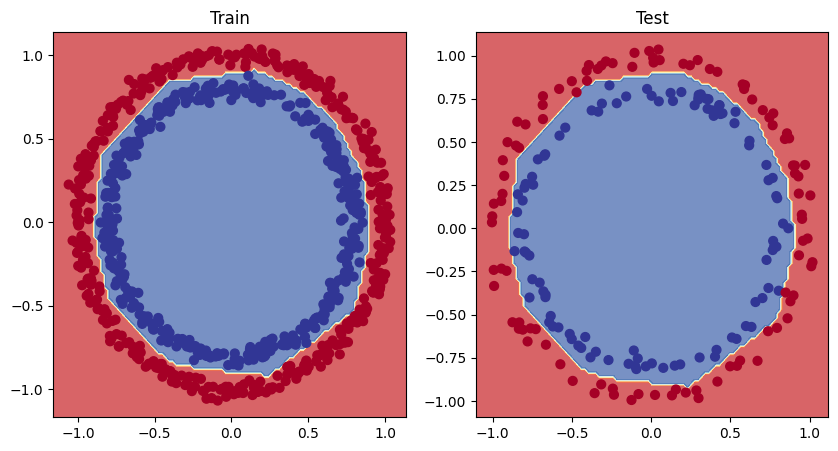

In [198]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train.cpu(), y_train.cpu())
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test.cpu(), y_test.cpu())

In [199]:
model.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-1.7996, -1.4615],
                      [-0.9538,  2.2742],
                      [-2.5058,  1.2911],
                      [ 0.2485,  0.2298],
                      [ 2.1658,  1.9141],
                      [ 0.1554,  0.0910],
                      [-1.4336,  0.6543],
                      [ 0.5250,  0.0290],
                      [ 0.6074,  0.1576],
                      [ 1.1686, -2.6120]])),
             ('layer1.bias',
              tensor([-0.9146, -0.7336,  0.1220, -0.4035, -0.7118, -0.5283,  2.1767,  1.2792,
                      -0.6657, -0.2518])),
             ('layer2.weight',
              tensor([[-5.9058e-01,  1.1012e+00, -8.4617e-01,  1.6505e-01,  2.9460e+00,
                        1.1825e-01, -1.9235e+00,  4.8058e-01,  3.3830e-02, -1.8420e+00],
                      [ 2.5651e+00,  1.2307e+00,  1.6358e+00, -3.1306e-02,  2.5801e+00,
                        4.6145e-03, -7.3178e-01, -1.1056e+00,  8.8618e-02,  1.9337e+

In [206]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

In [207]:
a = torch.arange(-10, 10, 1, dtype=torch.float)
print(sigmoid(torch.tensor(a)))

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])


/var/folders/4k/m7f5dtm96j744jvsqr8rndw80000gn/T/ipykernel_29194/679813755.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(sigmoid(torch.tensor(a)))
